# Experiments with numerical solvers 

In [2]:
using Distributed  # for parallel computing
addprocs(4);
print(workers())

[2, 3, 4, 5]

In [3]:
@everywhere begin 
    using DifferentialEquations
    using ProgressMeter
    
    function ode_solve(
            A::Function, 
            method::OrdinaryDiffEqAlgorithm, 
            p0::AbstractArray{T, 1}, 
            q0::AbstractArray{T, 1}, 
            t0::T, 
            H::T,
            nsteps::Integer,
            retfull::Bool) where T<:AbstractFloat
        
        h = H/nsteps 
        prob = SecondOrderODEProblem((du,u,p,t)->A(u), p0, q0, (t0, t0+H));
        sol = solve(prob, method, tstops=t0:h:(t0+H), adaptive=false);
        if retfull 
            P = hcat([u.x[1] for u in sol.u]...)   
            Q = hcat([u.x[2] for u in sol.u]...)
            return P, Q
        else 
            p = sol[end].x[1]
            q = sol[end].x[2]
            return p, q
        end
    end
    
    include("./setups/fpu.jl")
    
    const Dt = 1e0;
    const OMEGA = 300.;

    phi_Dt(p::AbstractArray{Float64, 1}, q::AbstractArray{Float64, 1}, h::Float64) = ode_solve(
        q->A(q; omega=OMEGA), KahanLi8(), p, q, 0.0, Dt, round(Int, Dt/h), false)
    
    phi_Dt(p::AbstractArray{BigFloat, 1}, q::AbstractArray{BigFloat, 1}, h::Float64) = ode_solve(
        q->A(q; omega=BigFloat(OMEGA)), KahanLi8(), p, q, BigFloat(0.0), BigFloat(Dt), round(Int, Dt/h), false)
    
    function phi_Dt_N(
            p0::AbstractArray{T, 1}, 
            q0::AbstractArray{T, 1}, 
            N::Integer, 
            h::Float64) where T<:AbstractFloat
        
        progressbar = Progress(N)
        
        d = length(p0)
        P = zeros(T, d, N+1)
        Q = zeros(T, d, N+1)
        P[:, 1] = p0
        Q[:, 1] = q0
        
        for n in 1:N
            P[:, n+1], Q[:, n+1] = phi_Dt(P[:, n], Q[:, n], h)
            next!(progressbar)
        end

        return P, Q
    end 
end

In [4]:
p0, q0 = initial_condition(omega=OMEGA)

println("p0: ", p0)
println("q0: ", q0)
println("H0: ", compute_H(p0, q0, omega=OMEGA))
println("K0: ", compute_K(p0))
println("U0: ", compute_U(q0, omega=OMEGA))

p0: [0.0, 1.4142135623730951, 0.0, 0.0, 0.0, 0.0]
q0: [0.7047497585825924, 0.7094638037905027, 0.0, 0.0, 0.0, 0.0]
H0: 2.0000333333950584
K0: 1.0000000000000002
U0: 1.0000333333950582


In [5]:
p0_bf, q0_bf = initial_condition(omega=BigFloat(OMEGA))

println("p0: ", p0_bf)
println("q0: ", q0_bf)
println("H0: ", compute_H(p0_bf, q0_bf, omega=BigFloat(OMEGA)))
println("K0: ", compute_K(p0_bf))
println("U0: ", compute_U(q0_bf, omega=BigFloat(OMEGA)))

p0: BigFloat[0.0, 1.4142135623730951454746218587388284504413604736328125, 0.0, 0.0, 0.0, 0.0]
q0: BigFloat[0.7047497585825923178108298688574862003455668579873906450922670933269467310748018, 0.7094638037905026343179257208230881147291492449973397463972320906067256389749586, 0.0, 0.0, 0.0, 0.0]
H0: 2.000033333395061660027860723353777969278741377395078617808329568871509005431726
K0: 1.000000000000000136716173153238464034424582539786161759775101024079468903238421
U0: 1.000033333395061523311687570115313934854158837608916858033228544792040102193322


In [6]:
using LinearAlgebra
using Plots

function compute_traj_err(sol, ref_sol) 
    return norm(sol .- ref_sol)/norm(ref_sol)
end 

function compute_H_err(sol, ref_sol; omega=OMEGA)
    omega = convert(typeof(sol[1][1]), omega)
    return abs(compute_H(sol...; omega=omega) - compute_H(ref_sol...; omega=omega)) / abs(compute_H(ref_sol...; omega=omega))
end 

compute_H_err (generic function with 1 method)

## 1. Find fine step size that's reasonably accurate

In [1]:
# h_list = [1e-2, 1e-3, 1e-4, 1e-5];
h_list = 2.0 .^[-8, -10, -12, -14, -16];
h_list

5-element Vector{Float64}:
 0.00390625
 0.0009765625
 0.000244140625
 6.103515625e-5
 1.52587890625e-5

In [13]:
res = [phi_Dt(p0, q0, h) for h in h_list];
ref_sol = res[end];

In [14]:
res_bf = [phi_Dt(p0_bf, q0_bf, h) for h in h_list];
ref_sol_bf = res_bf[end];

l2 norm of reference solution: 1.9065375191222398
relative trajectory errors: [0.0007786674357758228, 1.0796771430640107e-8, 1.3567982306719215e-12, 2.2799346524763455e-12, 0.0]


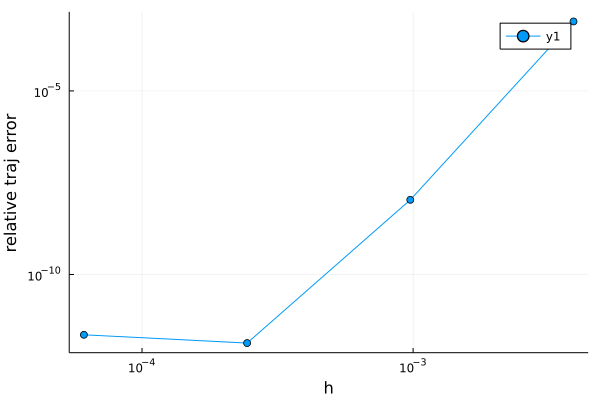

In [15]:
errors = [compute_traj_err(res[i], ref_sol) for i in 1:length(h_list)];
println("l2 norm of reference solution: ", norm(ref_sol))
println("relative trajectory errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")

energy of reference solution: 2.0000333333869618
relative energy errors: [1.2388314403577856e-8, 2.4291274923565013e-12, 1.2605262133553802e-12, 1.158609438310441e-12, 0.0]


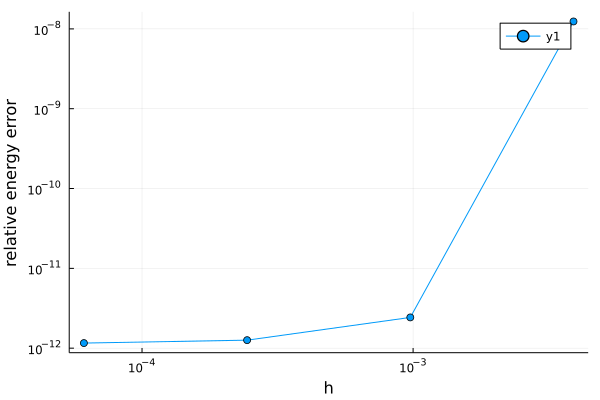

In [16]:
errors = [compute_H_err(res[i], ref_sol) for i in 1:length(h_list)];
println("energy of reference solution: ", compute_H(ref_sol...))
println("relative energy errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")

l2 norm of reference solution: 1.906537519123251694637856400280629890685606103936759060951300977844895727417308
relative trajectory errors: BigFloat[0.0007786674354144264032849576092244346434180315556447481433575793458575436117625925, 1.079673661367220702153436391642377188433907777290183292915428538366870739115347e-08, 1.634730691414629436146152909248758234665087574760291447862845590131008925205463e-13, 2.493136518535838264713983412264667013768432748366543090501415350602380912771369e-18, 0.0]


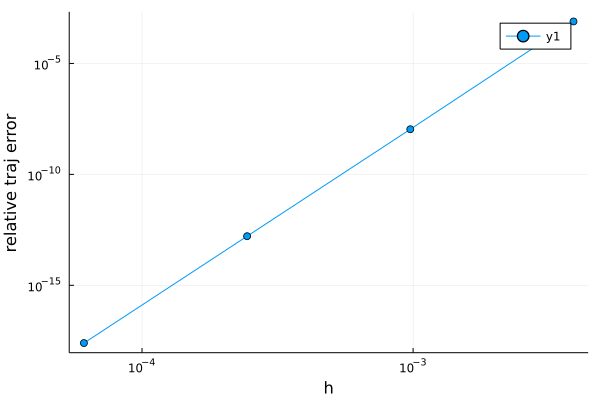

In [17]:
errors = [compute_traj_err(res_bf[i], ref_sol_bf) for i in 1:length(h_list)];
println("l2 norm of reference solution: ", norm(ref_sol_bf))
println("relative trajectory errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")

energy of reference solution: 2.000033333395061660027860726388021821675459931432366560888665590225689445617866
relative energy errors: BigFloat[1.23849630802010074754037235564880603815713109717941718512794342841313600186163e-08, 4.157692232053840408413321591061036769702933709147351261026685546037872217816112e-13, 6.505299256792137732604002144430019204427211801270291246899633775597588906075671e-18, 9.941344001116096204411507984667527402970950073228708926200684988600807465003998e-23, 0.0]


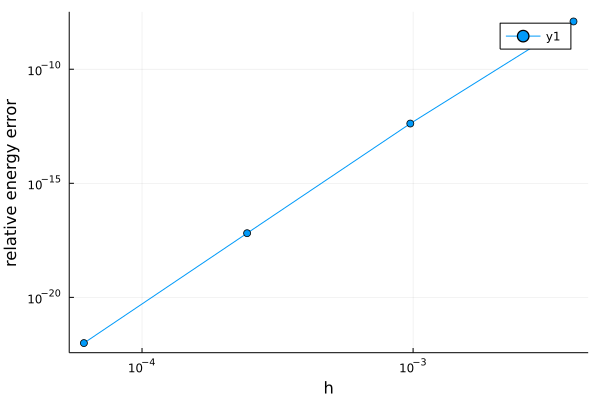

In [18]:
errors = [compute_H_err(res_bf[i], ref_sol_bf) for i in 1:length(h_list)];
println("energy of reference solution: ", compute_H(ref_sol_bf...; omega=BigFloat(300.)))
println("relative energy errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")

In [19]:
for i in 1:length(h_list)
    println("\n\nh=", h_list[i])
#     println("\nFloat64:", res[i])
#     println("\nBigFloat:", convert.(Vector{Float64}, res_f128[end]))
    println("\nDiff:", res[i] .- convert.(Vector{Float64}, res_bf[end]))
    println("\nnorm of diff:", 
        norm(res[i] .- convert.(Vector{Float64}, res_bf[end])))
end



h=0.00390625

Diff:([-0.0010497473048871608, 0.0010497093661466853, 3.994325728617909e-6, -3.9967605935942174e-6, 2.8070934604551567e-9, -2.6362920804712253e-9], [-3.4200867093936438e-6, 3.418752643646883e-6, -2.6172122469247938e-8, 2.671002879983675e-8, 1.0724516760762803e-11, 2.3646189173387455e-12])

norm of diff:0.0014845586793734954


h=0.0009765625

Diff:([-1.4554176308578803e-8, 1.4553646475456983e-8, 5.5559223888224096e-11, -5.560174543006724e-11, 4.009986787067987e-14, -3.7587988277465456e-14], [-4.735301040170725e-11, 4.734135305994869e-11, -3.6415315207705135e-13, 3.7109204598095857e-13, 1.5742615544489524e-16, 3.729655473350135e-17])

norm of diff:2.0582597890447972e-8


h=0.000244140625

Diff:([3.0317970356463775e-12, -3.0107791260114425e-12, -6.981082378842984e-13, 7.075451335936123e-13, 9.818534874028728e-16, 1.3530843112619095e-16], [-3.1086244689504383e-15, 3.219646771412954e-15, 3.608224830031759e-15, 6.716849298982197e-15, 6.505213034913027e-17, 6.852157730108388e-

In [20]:
sol = phi_Dt(p0, q0, 4e-3)
println("relative traj relerr = ", compute_traj_err(sol, ref_sol))
println("relative energy relerr = ", compute_H_err(sol, ref_sol))

relative traj relerr = 0.0009446941025114509
relative energy relerr = 1.3722960313217609e-8


## 2. Measure runtime

In [7]:
using BenchmarkTools

In [34]:
@benchmark phi_Dt(p0, q0, 2^(-18))

BenchmarkTools.Trial: 1 sample with 1 evaluation.
 Single result which took 7.058 s (36.88% GC) to evaluate,
 with a memory estimate of 12.33 GiB, over 114557417 allocations.

In [35]:
@benchmark phi_Dt(p0_bf, q0_bf, 2^(-18))

BenchmarkTools.Trial: 1 sample with 1 evaluation.
 Single result which took 55.175 s (29.66% GC) to evaluate,
 with a memory estimate of 46.97 GiB, over 778830647 allocations.

In [5]:
Nsamples = 1000
P_init = repeat(p0, outer=(1, Nsamples));
Q_init = repeat(q0, outer=(1, Nsamples));

In [5]:
@benchmark map(phi_Dt, eachslice($P_init, dims=2), eachslice($Q_init, dims=2))

BenchmarkTools.Trial: 1 sample with 1 evaluation.
 Single result which took 29.312 s (12.56% GC) to evaluate,
 with a memory estimate of 37.52 GiB, over 410089212 allocations.

In [7]:
@benchmark pmap(phi_Dt, eachslice($P_init, dims=2), eachslice($Q_init, dims=2))

BenchmarkTools.Trial: 3 samples with 1 evaluation.
 Range (min … max):  1.811 s …   1.901 s  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.867 s              ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.859 s ± 45.454 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █                                  █                    █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  1.81 s         Histogram: frequency by time         1.9 s <

 Memory estimate: 427.69 KiB, allocs estimate: 8218.

In [7]:
using Distributed
addprocs(4)

4-element Vector{Int64}:
 2
 3
 4
 5

In [12]:
using ProgressMeter

In [16]:
res = @showprogress pmap(a->sleep(a), 1:10)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:18


10-element Vector{Nothing}:
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing
 nothing

## 3. Measure stability 

In [8]:
include("./generate_data_utils.jl")
using Printf

In [9]:
p0_ptb = p0 .+ 1e-14;
q0_ptb = q0 .+ 1e-14;

In [10]:
p0_ptb_bf = p0_bf .+ 1e-14;
q0_ptb_bf = q0_bf .+ 1e-14;

In [11]:
N = 200
for h in 2.0 .^[-18]
#     P, Q = phi_Dt_N(p0, q0, N, h)
#     save_csv(". /stability/omega=300/kl8/f64/h=$(@sprintf("%.4e", h))/sol.csv", P, Q, Float64)
    
    P_ptb, Q_ptb = phi_Dt_N(p0_ptb, q0_ptb, N, h)
    save_csv("./stability/omega=300/kl8/f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb, Q_ptb, Float64)
    
end

Progress: 100%|█████████████████████████████████████████| Time: 0:24:57


LoadError: UndefVarError: P not defined

In [ ]:
N = 200
for h in 2.0 .^[-18]
    P_bf, Q_bf = phi_Dt_N(p0_bf, q0_bf, N, h)
    save_csv("./stability/omega=300/kl8/bigfloat/h=$(@sprintf("%.4e", h))/sol.csv", P_bf, Q_bf, BigFloat)
    save_csv("./stability/omega=300/kl8/bigfloat_f64/h=$(@sprintf("%.4e", h))/sol.csv", P_bf, Q_bf, Float64)
    
    P_ptb_bf, Q_ptb_bf = phi_Dt_N(p0_ptb_bf, q0_ptb_bf, N, h)
    save_csv("./stability/omega=300/kl8/bigfloat/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_bf, Q_ptb_bf, BigFloat)
    save_csv("./stability/omega=300/kl8/bigfloat_f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_bf, Q_ptb_bf, Float64)
end

Progress:  48%|███████████████████▉                     |  ETA: 1:35:03

In [3]:
P_bf_ref, Q_bf_ref = read_csv("./stability/omega=300/kl6/bigfloat/h=9.5367431640625e-7/sol.csv", BigFloat);
P_bf, Q_bf = read_csv("./stability/omega=300/kl6/bigfloat/h=3.814697265625e-6/sol.csv", BigFloat);

In [4]:
P_diff = P_bf[:, 1:201] - P_bf_ref[:, 1:201];
P_diff

6×201 Matrix{BigFloat}:
 0.0  -1.96921e-19  -3.76276e-19   6.10307e-19  …   1.21925e-14  -1.90589e-14
 0.0   1.96914e-19   3.76314e-19  -6.10307e-19      1.19993e-14  -1.93679e-14
 0.0   7.49696e-22  -4.26657e-21  -6.01684e-21     -4.16015e-16   3.59131e-16
 0.0  -7.50178e-22   4.22687e-21   6.01753e-21     -6.54688e-16   3.03321e-16
 0.0   5.20032e-25   5.92812e-24  -2.60418e-23     -1.08242e-14   1.80099e-14
 0.0  -4.9199e-25   -6.02944e-24   2.55594e-23  …  -1.09345e-14   1.82166e-14

In [5]:
Q_diff = Q_bf[:, 1:201]  - Q_bf_ref[:, 1:201];
Q_diff

6×201 Matrix{BigFloat}:
 0.0  -6.40643e-22   1.33317e-21   1.84671e-21  …   6.28157e-15   6.09134e-15
 0.0   6.40447e-22  -1.33346e-21  -1.8465e-21       6.28112e-15   6.09184e-15
 0.0  -4.88841e-24  -8.84334e-24   2.90885e-23     -3.53164e-16  -2.53298e-15
 0.0   4.96504e-24   8.88253e-24  -2.9556e-23      -3.53203e-16  -2.53216e-15
 0.0   1.72679e-27  -5.27963e-27  -4.10693e-26     -8.71154e-15  -6.49122e-15
 0.0   1.2542e-28    7.06809e-26   5.49663e-26  …  -8.7112e-15   -6.49085e-15

In [182]:
P_bf_f64 - convert.(Float64, P_f128)

6×101 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [156]:
convert.(BigFloat, convert.(Float64, P_f128))[:, 2]

6-element Vector{BigFloat}:
 -1.4591698294104471500531872152350842952728271484375
 -0.0624068593408681759893141816064598970115184783935546875
  0.5605875226019476631478255512774921953678131103515625
  0.57121235003515191674949846856179647147655487060546875
  0.0198972778182629379817303316713150707073509693145751953125
  0.0198846465757328803858339227872420451603829860687255859375

In [157]:
convert.(Float64, P_f128)[:, 2]

6-element Vector{Float64}:
 -1.4591698294104472
 -0.062406859340868176
  0.5605875226019477
  0.5712123500351519
  0.019897277818262938
  0.01988464657573288

In [176]:
Q_bf - Q_f128

6×101 Matrix{BigFloat}:
 0.0   0.0          0.0  -1.07952e-78  …   0.0          0.0   0.0
 0.0   0.0          0.0   0.0              0.0          0.0  -2.15904e-78
 0.0  -4.31808e-78  0.0   0.0              0.0          0.0   0.0
 0.0   0.0          0.0   0.0              0.0          0.0   0.0
 0.0   0.0          0.0   0.0             -5.39761e-79  0.0   4.31808e-78
 0.0   0.0          0.0   0.0          …   0.0          0.0   0.0

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


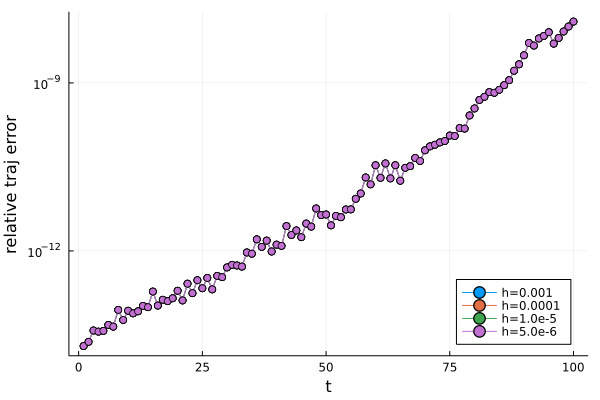

In [99]:
errors = []
for (h, P, Q, P_ptb, Q_ptb) in stability_res_f128
    errors_h = []
    for n in 1:100
        err = compute_traj_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
        push!(errors_h, err)
    end
    push!(errors, (h, errors_h))
end 

plot()
for (h, errors_h) in errors
    plot!((1:N), errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


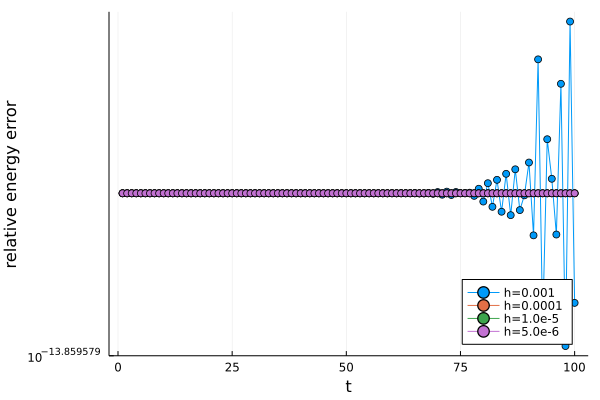

┌ Warning: No strict ticks found
└ @ PlotUtils /workspace/project_Rui/.julia/packages/PlotUtils/VgXdq/src/ticks.jl:294
┌ Warning: No strict ticks found
└ @ PlotUtils /workspace/project_Rui/.julia/packages/PlotUtils/VgXdq/src/ticks.jl:294


In [101]:
errors = []
for (h, P, Q, P_ptb, Q_ptb) in stability_res_f128
    errors_h = []
    for n in 1:100
        err = compute_H_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
        push!(errors_h, err)
    end
    push!(errors, (h, errors_h))
end 

plot()
for (h, errors_h) in errors
    plot!((1:100), errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="t", ylabel="relative energy error")
plot!(legend=:bottomright)

## 4. BigFloat

In [40]:
P, Q = phi_Dt_N(p0, q0, 50, 5e-6, 1.0, 0.0)

([0.0 -1.459169829415611 … 0.15388314221468322 1.0567920117951832; 1.4142135623730951 -0.062406859335768505 … -0.04081550669933136 -0.9133854894865938; … ; 0.0 0.019897277818259094 … -0.9008043241614703 0.1247403847669647; 0.0 0.019884646575740593 … -0.8990648191791544 0.1409354341159973], [0.7047497585825924 0.531123698929628 … -0.2214689914432798 -0.16045150347886764; 0.7094638037905027 0.5263588641879523 … -0.22805254835993555 -0.15966030847558457; … ; 0.0 0.0028011438887687087 … -0.23210811611528281 -0.855268310937831; 0.0 0.0027986129241268773 … -0.2320557412114487 -0.8552713550409551])

In [41]:
P_f128, Q_f128 = phi_Dt_N(p0_f128, q0_f128, 50, BigFloat(5e-6), BigFloat(1.0), BigFloat(0.0))

(BigFloat[0.0 -1.459169829410368779410161784367368445764580777356868377090088865346787703527058 … 0.153883142197898447459867869267899584845706459839831770316691039554414047787873 1.056792011754082424217698320397003829080256478283381746411884258694009175119336; 1.4142135623730951454746218587388284504413604736328125 -0.06240685934094658668617253151020743106591186865585106338968688369431157319456272 … -0.04081550666286182836152679895766042230333674188620469368276366976877001072722253 -0.9133854894206951802539449931766712595576551917786161802830000035166924614302262; … ; 0.0 0.01989727781826293693669555687120337467943414660988347940208474367409642489088191 … -0.9008043241778759871677151317483574854960168111654298444517701885203549290247782 0.1247403847319666422548981197141929261282983349274500706020902000057239613333535; 0.0 0.01988464657573288011280146527608779131637330867655726159684885660544150592626029 … -0.899064819160774009810251844274920577132124088051368876367795189672339369095168 

In [79]:
P_largeh, Q_largeh = phi_Dt_N(p0, q0, 50, 1e-3, 1.0, 0.0)

([0.0 -1.4590432234948845 … 0.16256231460742523 1.055688663552182; 1.4142135623730951 -0.06253346065340452 … -0.04949467815730865 -0.9122821829356766; … ; 0.0 0.019897277477579328 … -0.9008724627930322 0.124749975854537; 0.0 0.019884646900719 … -0.8989966827582336 0.14092593609340973], [0.7047497585825924 0.5311241099370279 … -0.2214719548544625 -0.16048094557824935; 0.7094638037905027 0.5263584532477026 … -0.22804954128077834 -0.15963085832378013; … ; 0.0 0.002801143889443199 … -0.23210808941902575 -0.8552680708855828; 0.0 0.0027986129258186017 … -0.23205576778981854 -0.8552715991319789])

In [80]:
P_largeh_f128, Q_largeh_f128 = phi_Dt_N(p0_f128, q0_f128, 50, BigFloat(1e-3), BigFloat(1.0), BigFloat(0.0))

(BigFloat[0.0 -1.459043223494921486034732857067443027089302437303272158650577608463691832208682 … 0.1625623146058414712332515675335524554811923429696682872193397739052510001950151 1.055688663553414104621560153630360664739638090105459069036935609892212752837863; 1.4142135623730951454746218587388284504413604736328125 -0.06253346065336396933226171288617925326730032544544775700384903021752907977285967 … -0.04949467815479272141592775160507397992099806594741267267390737380797048436786536 -0.9122821829357280323125240359818209005580117638258297850598021427894253953344967; … ; 0.0 0.01989727747757892664766949901717341389344570475481204965900869393471343208250479 … -0.9008724627924572862999861597548865105092238393871901951017414021921896142338823 0.1247499758579157242114842835912386134237314984519857929019926258467121317885324; 0.0 0.01988464690071951244364354779394272547761549035005274246472580097735468147009534 … -0.898996682758682008963054548726487533917141788700133127317513882270957299301321

In [81]:
P_convert = convert( Matrix{BigFloat}, P);
Q_convert = convert( Matrix{BigFloat}, Q);
P_largeh_convert = convert( Matrix{BigFloat}, P_largeh);
Q_largeh_convert = convert( Matrix{BigFloat}, Q_largeh);

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76
┌ Warning: Skipped yaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


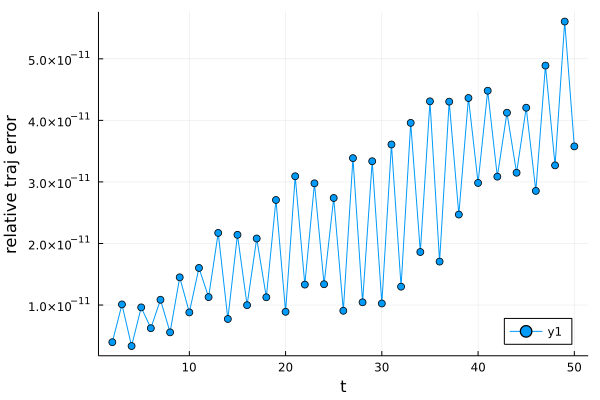

In [51]:
errors = []
for n in 1:50
    err = compute_traj_err((P[:, n], Q[:, n]), (P_f128[:, n], Q_f128[:, n]))
    push!(errors, err)
end

plot()
plot!((2:50), errors[2:end], marker=:circle)
plot!(xaxis=:linear, yaxis=:linear)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76
┌ Warning: Skipped yaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


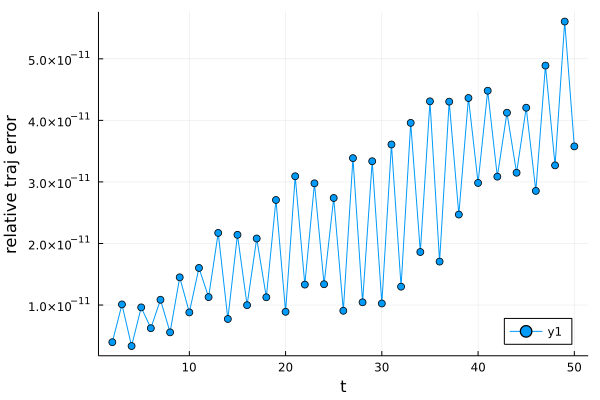

In [70]:
errors = []
for n in 1:50
    err = compute_traj_err((P_convert[:, n], Q_convert[:, n]), (P_f128[:, n], Q_f128[:, n]))
    push!(errors, err)
end

plot()
plot!((2:50), errors[2:end], marker=:circle)
plot!(xaxis=:linear, yaxis=:linear)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76
┌ Warning: Skipped yaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


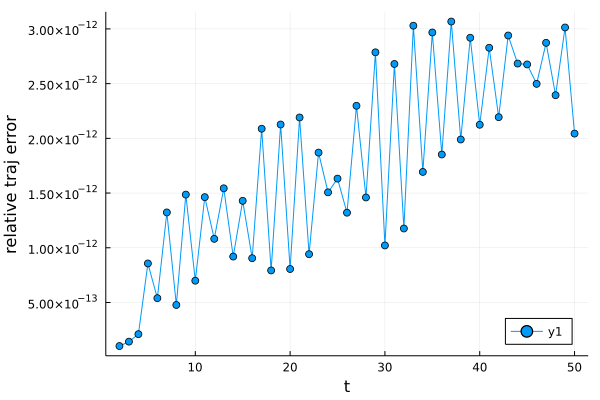

In [82]:
errors = []
for n in 1:50
    err = compute_traj_err((P_largeh_convert[:, n], Q_largeh_convert[:, n]), 
        (P_largeh_f128[:, n], Q_largeh_f128[:, n]))
    push!(errors, err)
end

plot()
plot!((2:50), errors[2:end], marker=:circle)
plot!(xaxis=:linear, yaxis=:linear)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

## Find CalvoSanz and Velocity Verlet step sizes that generate similar level of accuracy as NN

In [19]:
@everywhere begin 
    
    phi_Dt_CS(p, q, h_CS) = ode_solve(A, CalvoSanz4(), p, q, 0.0, Dt, round(Int, Dt/h_CS), false)
    phi_Dt_VV(p, q, h_VV) = ode_solve(A, VelocityVerlet(), p, q, 0.0, Dt, round(Int, Dt/h_VV), false)
    
end

In [1]:
using CSV 
using DataFrames

In [2]:
df_init = DataFrame(CSV.File("../data/fpu/Dt1e0_dt1e-2_h5e-5/400traj/test/X.csv"));
df_final = DataFrame(CSV.File("../data/fpu/Dt1e0_dt1e-2_h5e-5/400traj/test/Y.csv"));

In [14]:
div(size(df_init)[2], 2)

6

In [15]:
df_init[:, 1:3]

,p1,p2,p3
,Float64,Float64,Float64
1,1.20737,-0.279278,-0.745425
2,0.214214,-1.1025,0.434747
3,-0.357103,0.800476,-0.340655
4,-1.49277,-0.210345,0.0403567
5,0.0136592,1.45386,0.601766
6,0.357872,0.519819,-0.17021
7,0.0412103,1.39902,-0.474584
8,-0.680954,0.810106,0.168413
9,0.460773,0.0431027,-0.000468713


In [12]:
l = 1
nsamples = 40080
P_init = Matrix(df_init[1:l:nsamples, 1:6])'; 
Q_init = Matrix(df_init[1:l:nsamples, 7:12])';
P_final = Matrix(df_final[1:l:nsamples, 1:6])'; 
Q_final = Matrix(df_final[1:l:nsamples, 7:12])';

In [21]:
function accuracy_VV(timestep)
    res = pmap((p, q)->phi_Dt_VV(p, q, timestep), eachslice(P_init, dims=2), eachslice(Q_init, dims=2));

    P_VV = hcat([p for (p, q) in res]...);
    Q_VV = hcat([q for (p, q) in res]...);

    SE = sum((P_VV - P_final) .^2, dims=1) + sum((Q_VV - Q_final) .^2, dims=1);
    MSE = sum(SE)/length(SE);

    return MSE 
end 

accuracy_VV (generic function with 1 method)

In [23]:
function accuracy_CS(timestep)
    res = pmap((p, q)->phi_Dt_CS(p, q, timestep), eachslice(P_init, dims=2), eachslice(Q_init, dims=2));

    P_CS = hcat([p for (p, q) in res]...);
    Q_CS = hcat([q for (p, q) in res]...);

    SE = sum((P_CS - P_final) .^2, dims=1) + sum((Q_CS - Q_final) .^2, dims=1);
    MSE = sum(SE)/length(SE);

    return MSE 
end 

accuracy_CS (generic function with 1 method)

In [22]:
for nsteps_VV in [32, 64, 128]
    h_VV = Dt/nsteps_VV
    println(h_VV, " ", nsteps_VV, " ", accuracy_VV(h_VV))
end

0.03125 32 0.6278326283974353
0.015625 64 1.4437819082575212
0.0078125 128 0.10294198825932901


In [24]:
for nsteps_CS in [8, 16, 32]
    h_CS = Dt/nsteps_CS
    println(h_CS, " ", nsteps_CS, " ", accuracy_CS(h_CS))
end

0.125 8 12.113986319436153
0.0625 16 20.929485064488254
0.03125 32 0.0005649300775061397


In [25]:
for nsteps_CS in [64, 128]
    h_CS = Dt/nsteps_CS
    println(h_CS, " ", nsteps_CS, " ", accuracy_CS(h_CS))
end

0.015625 64 2.034209929224812e-6
0.0078125 128 7.768522155694077e-9


In [30]:
@time for i in 1:1000 phi_Dt_VV(v0, x0, 1.5625e-5) end 

  1.069980 seconds (14.36 M allocations: 1.330 GiB, 22.04% gc time)


In [33]:
@time for i in 1:64 phi_Dt_CS(p0, q0, Dt/64) end 

  0.832354 seconds (11.10 M allocations: 1022.842 MiB, 21.92% gc time)


In [16]:
using Plots

In [107]:
histogram(vec(SE))

LoadError: InexactError: trunc(Int64, 2.3271148548353484e40)

In [139]:
H_init = pmap(compute_hamiltonian, eachslice(V_init, dims=2), eachslice(X_init, dims=2));
H_final = pmap(compute_hamiltonian, eachslice(V_final, dims=2), eachslice(X_final, dims=2));

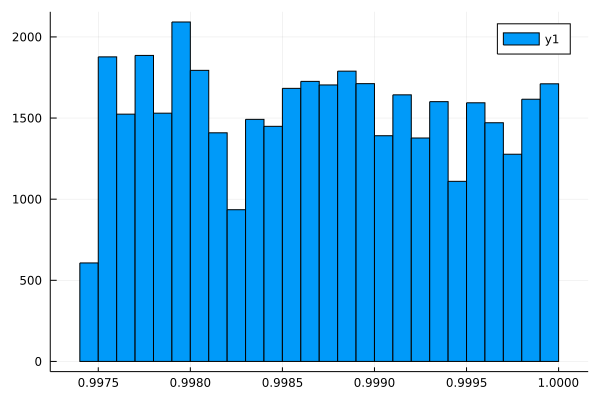

In [140]:
histogram(vec(H_init/H0))

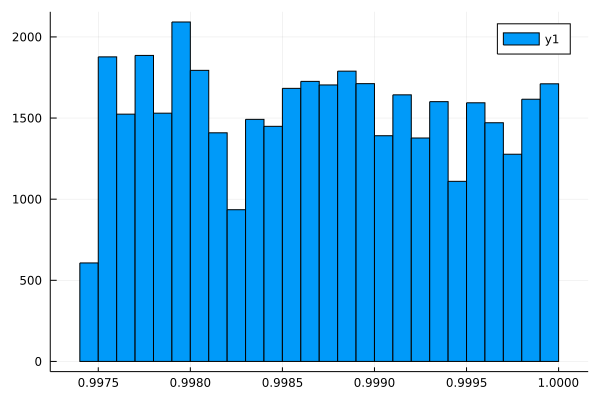

In [141]:
histogram(vec(H_final/H0))